<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
General Model Comparison: CV RMSE Across Regressors
</p>

In [17]:
# Imports - core utils, data wrangling, and plotting

import os
import re

import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Setup: Data Paths &amp; Plot Style
</p>

In [18]:
# Setup - shared data paths, global plot style, and reusable plotting helpers

CV_RESULTS_DIR = "CV_Results"
FIGURES_DIR    = "Figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

CV_RESULTS_PATHS = {  # RF / XGBoost / LightGBM Bayesian CV results
    "RF":       os.path.join(CV_RESULTS_DIR, "rf_bayes_cv_results.csv"),
    "XGBoost":  os.path.join(CV_RESULTS_DIR, "xgb_bayes_cv_results.csv"),
    "LightGBM": os.path.join(CV_RESULTS_DIR, "lgb_bayes_cv_results.csv"),
}
MAX_DEPTH_CAP = 10  # full max_depth search range for RF/XGBoost/LightGBM (Integer(1, 10));
                     # depths  plotted are chosen in the plotting cell

# Wide-range kNN sweep from 06a_kNN.ipynb (K=20-3000, fold-level rows), not the original
# narrow BayesSearchCV cv_results_ table (K=20-300) -- see the loading cell for the schema.
KNN_CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "knn_cv_k_weighting_scan.csv")
SVR_C_SWEEP_PATH    = os.path.join(CV_RESULTS_DIR, "svr_c_sweep_cv.csv")

ANN_BEST_PROFILE_PATH = os.path.join(CV_RESULTS_DIR, "ann_compact_best_profile_per_architecture.csv")
ANN_CV_RESULTS_PATH   = os.path.join(CV_RESULTS_DIR, "ann_compact_kfold_results_summary.csv")
RNN_BEST_PROFILE_PATH = os.path.join(CV_RESULTS_DIR, "rnn_best_profile_per_architecture.csv")
RNN_CV_RESULTS_PATH   = os.path.join(CV_RESULTS_DIR, "rnn_kfold_results_summary.csv")

# Global plot style - shared by every figure
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

bar_color = "#1976d2"  # single-series bar color used across the kNN/SVR/ANN/RNN panels


def annotate_bar(ax, xi, cv, sd, value_fontsize=12, std_fontsize=12):
    # Mean CV RMSE, set inside the bar near its lower error whisker
    ax.annotate(
        f"{cv:.2f}",
        (xi, cv - sd),
        textcoords="offset points",
        xytext=(0, -4),
        ha="center",
        va="top",
        fontsize=value_fontsize,
        color="white",
        fontweight="bold",
        rotation=90,
        zorder=4,
    )
    # SD, set above the upper error whisker
    ax.annotate(
        rf"$\pm${sd:.2f}",
        (xi, cv + sd),
        textcoords="offset points",
        xytext=(0, 3),
        ha="center",
        va="bottom",
        fontsize=std_fontsize,
        color="black",
        rotation=90,
        zorder=4,
    )


def style_panel(ax, xlabel, panel_label, tick_fontsize=12, axis_labelsize=15):
    # panel_label ("(a)", "(b)", ...) is folded into the x-axis label as a second
    # line, so it sits at the bottom of the panel instead of as a title on top.
    ax.set_xlabel(f"{xlabel}\n{panel_label}", fontsize=axis_labelsize)
    ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load: RF, XGBoost &amp; LightGBM CV Results
</p>

In [19]:
# Best-per-depth (max score / min RMSE) CV RMSE and SD for RF, XGBoost, and LightGBM

def best_per_depth(cv_results_path, max_depth_cap=MAX_DEPTH_CAP):
    """Best (max score / min RMSE) CV RMSE and its SD per max_depth, from a saved
    BayesSearchCV cv_results_ table."""
    if not os.path.exists(cv_results_path):
        raise FileNotFoundError(f"Missing CV results file: {cv_results_path}")

    df = pd.read_csv(cv_results_path)
    required_cols = {
        "param_max_depth",
        "mean_test_neg_root_mean_squared_error",
        "std_test_neg_root_mean_squared_error",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{cv_results_path} is missing columns: {sorted(missing)}")

    df["param_max_depth"] = pd.to_numeric(df["param_max_depth"], errors="coerce")
    df = df[df["param_max_depth"] <= max_depth_cap]

    rows = []
    for depth in sorted(df["param_max_depth"].dropna().unique()):
        df_depth = df[df["param_max_depth"] == depth]
        idx = df_depth["mean_test_neg_root_mean_squared_error"].idxmax()
        row = df_depth.loc[idx]
        rows.append({
            "max_depth": int(depth),
            "CV_RMSE": -float(row["mean_test_neg_root_mean_squared_error"]),
            "STD_RMSE": float(row["std_test_neg_root_mean_squared_error"]),
        })

    return pd.DataFrame(rows)


# Best-per-depth CV RMSE summary for each ensemble model
per_model_cv = {name: best_per_depth(path) for name, path in CV_RESULTS_PATHS.items()}

combined_cv_df = pd.concat(
    [df.assign(model=name) for name, df in per_model_cv.items()],
    ignore_index=True,
)[["model", "max_depth", "CV_RMSE", "STD_RMSE"]]

if combined_cv_df.empty:
    raise ValueError("No CV rows found for any ensemble model.")

display(combined_cv_df.pivot(index="max_depth", columns="model", values="CV_RMSE").round(4))

model,LightGBM,RF,XGBoost
max_depth,,,
1,6.7025,12.2540,6.6694
2,5.9153,8.1638,5.8640
3,5.8304,5.9637,5.8319
4,6.0003,5.9058,5.8578
5,5.9306,5.9082,5.8431
6,5.9940,5.9103,5.8498
7,5.8391,5.9087,6.1483
8,6.0721,5.9297,6.1173
9,6.1117,5.9520,5.9691


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Combined CV RMSE by max_depth
</p>

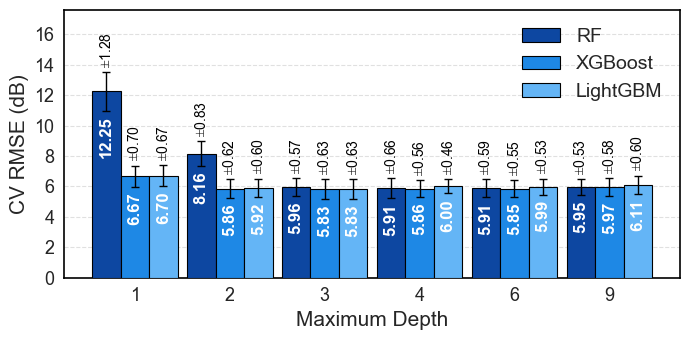

Saved figure: Figures/Ensembles_bestRMSE_STD_perDepth_comparison.png


In [20]:
# Plot and save the combined RF / XGBoost / LightGBM CV RMSE figure by max_depth

tick_fontsize   = 13
axis_labelsize  = 15
legend_fontsize = 14
value_fontsize  = 12
std_fontsize    = 10
y_tick_step     = 2  # dB spacing between y-axis ticks

# Selected max_depth values to appear on the x-axis
SELECTED_DEPTHS = [1, 2, 3, 4, 6, 9]

# Blue-gradient theme: model identity is encoded by lightness (light -> dark)
model_order  = ["RF", "XGBoost", "LightGBM"]
model_colors = {
    "RF":       "#0d47a1",  # dark blue
    "XGBoost":  "#1e88e5",  # mid blue
    "LightGBM": "#64b5f6",  # light blue
}

available_depths = set(combined_cv_df["max_depth"].unique())
depths = sorted(d for d in SELECTED_DEPTHS if d in available_depths)

missing_depths = sorted(set(SELECTED_DEPTHS) - available_depths)
if missing_depths:
    print(f"Note: no CV results for max_depth {missing_depths}; skipping.")
if not depths:
    raise ValueError("None of SELECTED_DEPTHS were found in combined_cv_df.")

plot_df = combined_cv_df[combined_cv_df["max_depth"].isin(depths)]

x = np.arange(len(depths))
n_models = len(model_order)
bar_width = 0.3

fig, ax = plt.subplots(figsize=(7, 3.5))

for i, model in enumerate(model_order):
    sub = (
        plot_df[plot_df["model"] == model]
        .set_index("max_depth")
        .reindex(depths)
    )
    offset = (i - (n_models - 1) / 2) * bar_width
    bar_x = x + offset

    ax.bar(
        bar_x,
        sub["CV_RMSE"],
        bar_width,
        yerr=sub["STD_RMSE"],
        capsize=3,
        color=model_colors[model],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
        error_kw=dict(elinewidth=1, capthick=1),
        label=model,
    )

    for xi, cv, sd in zip(bar_x, sub["CV_RMSE"], sub["STD_RMSE"]):
        if pd.isna(cv):
            continue

        # Mean CV RMSE, set inside the bar near its lower error whisker
        ax.annotate(
            f"{cv:.2f}",
            (xi, cv - sd),
            textcoords="offset points",
            xytext=(0, -4),
            ha="center",
            va="top",
            fontsize=value_fontsize,
            color="white",
            fontweight="bold",
            rotation=90,
            zorder=4,
        )

        # SD, set above the upper error whisker
        ax.annotate(
            rf"$\pm${sd:.2f}",
            (xi, cv + sd),
            textcoords="offset points",
            xytext=(0, 3),
            ha="center",
            va="bottom",
            fontsize=std_fontsize,
            color="black",
            rotation=90,
            zorder=4,
        )

ax.set_xlabel("Maximum Depth", fontsize=axis_labelsize)
ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(d)}" for d in depths], fontsize=tick_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
ax.grid(False, axis="x")
ax.set_axisbelow(True)

y_top = float((plot_df["CV_RMSE"] + plot_df["STD_RMSE"]).max())
ax.set_ylim(0, y_top * 1.3)
ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

ax.legend(loc="upper right", fontsize=legend_fontsize, frameon=False)

fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "Ensembles_bestRMSE_STD_perDepth_comparison.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

plt.show()
print(f"Saved figure: {fig_path}")

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load: kNN &amp; SVR CV Results
</p>

In [21]:
# Best-per-K CV RMSE for kNN, best-per-C CV RMSE for SVR

def best_per_param(cv_results_path, param_col, out_name, param_cast=float):
    """Best (max score / min RMSE) CV RMSE and its SD per distinct value of
    `param_col`, from a saved BayesSearchCV cv_results_ table."""
    if not os.path.exists(cv_results_path):
        raise FileNotFoundError(f"Missing CV results file: {cv_results_path}")

    df = pd.read_csv(cv_results_path)
    required_cols = {
        param_col,
        "mean_test_neg_root_mean_squared_error",
        "std_test_neg_root_mean_squared_error",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{cv_results_path} is missing columns: {sorted(missing)}")

    df[param_col] = pd.to_numeric(df[param_col], errors="coerce")

    rows = []
    for value in sorted(df[param_col].dropna().unique()):
        df_value = df[df[param_col] == value]
        idx = df_value["mean_test_neg_root_mean_squared_error"].idxmax()
        row = df_value.loc[idx]
        rows.append({
            out_name: param_cast(value),
            "CV_RMSE": -float(row["mean_test_neg_root_mean_squared_error"]),
            "STD_RMSE": float(row["std_test_neg_root_mean_squared_error"]),
        })

    return pd.DataFrame(rows)


def load_knn_wide_sweep(cv_results_path, weighting="uniform"):
    """Mean/SD CV RMSE per K, from 06a_kNN.ipynb's wide-range fold-level sweep
    (columns: fold, K, weighting, rmse, r2) -- a different schema from the raw
    BayesSearchCV cv_results_ tables used by best_per_param above."""
    if not os.path.exists(cv_results_path):
        raise FileNotFoundError(f"Missing CV results file: {cv_results_path}")

    df = pd.read_csv(cv_results_path)
    required_cols = {"K", "weighting", "rmse"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{cv_results_path} is missing columns: {sorted(missing)}")

    df = df[df["weighting"] == weighting]
    agg = df.groupby("K")["rmse"].agg(["mean", "std"]).reset_index()
    agg.columns = ["K", "CV_RMSE", "STD_RMSE"]
    return agg.sort_values("K").reset_index(drop=True)


def load_svr_c_sweep(c_sweep_path):
    """Best CV RMSE and its SD per C, from the SVR C-sensitivity sweep table
    (already one row per C, unlike the raw BayesSearchCV cv_results_ tables)."""
    if not os.path.exists(c_sweep_path):
        raise FileNotFoundError(f"Missing C-sweep file: {c_sweep_path}")

    df = pd.read_csv(c_sweep_path)
    required_cols = {"C", "rmse_mean", "rmse_std"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{c_sweep_path} is missing columns: {sorted(missing)}")

    out = pd.DataFrame({
        "log10_C": np.log10(df["C"].astype(float)),
        "CV_RMSE": df["rmse_mean"].astype(float),
        "STD_RMSE": df["rmse_std"].astype(float),
    })
    return out.sort_values("log10_C").reset_index(drop=True)


# Best-per-K summary for kNN (wide-range sweep, uniform weighting), best-per-C summary for SVR
cv_knn_df = load_knn_wide_sweep(KNN_CV_RESULTS_PATH, weighting="uniform")
cv_svr_df = load_svr_c_sweep(SVR_C_SWEEP_PATH)

display(cv_knn_df.round(4))
display(cv_svr_df.round(4))

,K,CV_RMSE,STD_RMSE
0,20,6.6967,0.5846
1,21,6.6890,0.5836
2,22,6.6818,0.5827
3,23,6.6751,0.5821
4,24,6.6684,0.5806
...,...,...,...
95,2450,6.4355,0.5946
96,2577,6.4455,0.6000
97,2711,6.4562,0.6060
98,2852,6.4677,0.6125


,log10_C,CV_RMSE,STD_RMSE
0,-3.0,20.1984,1.5121
1,-2.0,19.1383,1.6121
2,-1.0,12.2740,2.4692
3,0.0,10.3964,2.9743
4,1.0,9.4962,2.7625
5,2.0,8.8713,2.3174
6,3.0,9.8409,2.4247


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: kNN vs. SVR CV RMSE
</p>

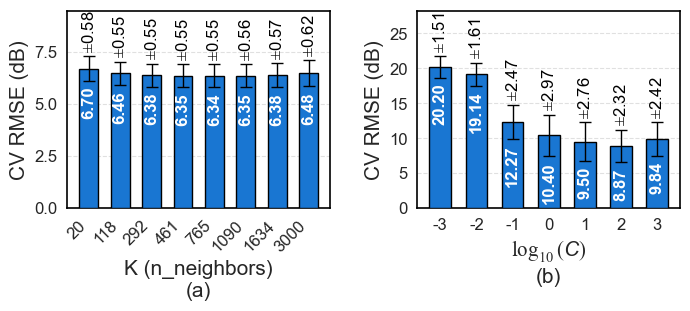

Saved figure: Figures/KNN_SVR_bestRMSE_STD_combination.png


In [22]:
# Plot and save kNN (vs K) and SVR (vs log10 C) CV RMSE side by side, 2 columns
# Reuses bar_color / annotate_bar / style_panel defined in the Setup cell above.

tick_fontsize = 12
y_tick_step   = 5
yk_tick_step  = 2.5

# Selected K / log10(C) values  to appear on each panel.
SELECTED_K       = [20, 118, 292, 461, 765, 1090, 1634, 3000]
SELECTED_LOG10_C = sorted(cv_svr_df["log10_C"].round().astype(int).unique())

fig, (ax_knn, ax_svr) = plt.subplots(1, 2, figsize=(7, 3.2))

#  kNN panel 
knn_plot_df = cv_knn_df[cv_knn_df["K"].isin(SELECTED_K)].sort_values("K").reset_index(drop=True)
if knn_plot_df.empty:
    raise ValueError("None of SELECTED_K were found in cv_knn_df.")

x_knn = np.arange(len(knn_plot_df))
ax_knn.bar(
    x_knn,
    knn_plot_df["CV_RMSE"],
    width=0.6,
    yerr=knn_plot_df["STD_RMSE"],
    capsize=4,
    color=bar_color,
    edgecolor="black",
    linewidth=1,
    zorder=3,
    error_kw=dict(elinewidth=1, capthick=1),
)
for xi, cv, sd in zip(x_knn, knn_plot_df["CV_RMSE"], knn_plot_df["STD_RMSE"]):
    annotate_bar(ax_knn, xi, cv, sd)

ax_knn.set_xticks(x_knn)
# Rotated: K now spans up to 4 digits (3000), which overlaps at this panel width
# when set horizontally, unlike the original 2-3 digit range (20-300).
ax_knn.set_xticklabels(
    [f"{int(k)}" for k in knn_plot_df["K"]], fontsize=tick_fontsize, rotation=45, ha="right"
)
y_top_knn = float((knn_plot_df["CV_RMSE"] + knn_plot_df["STD_RMSE"]).max())
ax_knn.set_ylim(0, y_top_knn * 1.3)
ax_knn.yaxis.set_major_locator(MultipleLocator(yk_tick_step))
style_panel(ax_knn, "K (n_neighbors)", "(a)")

#  SVR panel 
svr_plot_df = (
    cv_svr_df[cv_svr_df["log10_C"].round().astype(int).isin(SELECTED_LOG10_C)]
    .sort_values("log10_C")
    .reset_index(drop=True)
)
if svr_plot_df.empty:
    raise ValueError("None of SELECTED_LOG10_C were found in cv_svr_df.")

x_svr = np.arange(len(svr_plot_df))
ax_svr.bar(
    x_svr,
    svr_plot_df["CV_RMSE"],
    width=0.6,
    yerr=svr_plot_df["STD_RMSE"],
    capsize=4,
    color=bar_color,
    edgecolor="black",
    linewidth=1,
    zorder=3,
    error_kw=dict(elinewidth=1, capthick=1),
)
for xi, cv, sd in zip(x_svr, svr_plot_df["CV_RMSE"], svr_plot_df["STD_RMSE"]):
    annotate_bar(ax_svr, xi, cv, sd)

ax_svr.set_xticks(x_svr)
ax_svr.set_xticklabels([f"{v:.0f}" for v in svr_plot_df["log10_C"]], fontsize=tick_fontsize)
y_top_svr = float((svr_plot_df["CV_RMSE"] + svr_plot_df["STD_RMSE"]).max())
ax_svr.set_ylim(0, y_top_svr * 1.3)
ax_svr.yaxis.set_major_locator(MultipleLocator(y_tick_step))
style_panel(ax_svr, r"$\log_{10}(C)$", "(b)")

fig.tight_layout(w_pad=2.5) # gap between the two panels 

fig_path = os.path.join(FIGURES_DIR, "KNN_SVR_bestRMSE_STD_combination.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

plt.show()
print(f"Saved figure: {fig_path}")

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load: ANN &amp; RNN CV Results
</p>

In [23]:
# Best CV RMSE per architecture for ANN and RNN

def _arch_to_tuple(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return tuple(int(v) for v in value)
    return tuple(int(n) for n in re.findall(r"\d+", str(value)))


def load_arch_best_rmse(preferred_path, fallback_path, target_archs):
    """Best CV RMSE and its SD for each architecture in `target_archs`, preferring
    a pre-computed best-profile-per-architecture table and falling back to
    deriving it from the raw kfold results summary (mirroring the ANN/RNN
    notebooks' own loading cells)."""
    if os.path.exists(preferred_path):
        df = pd.read_csv(preferred_path)
    elif os.path.exists(fallback_path):
        df = pd.read_csv(fallback_path)
        if "Regularization Profile" in df.columns:
            rank_col = "Median Val RMSE" if "Median Val RMSE" in df.columns else "Mean Val RMSE"
            df = (
                df.sort_values(by=rank_col, ascending=True)
                .groupby("Architecture", as_index=False)
                .head(1)
            )
    else:
        raise FileNotFoundError(f"Missing CV results: {preferred_path} (or fallback {fallback_path})")

    rmse_col = "Median Val RMSE" if "Median Val RMSE" in df.columns else "Mean Val RMSE"
    std_col = "Std Val RMSE"
    required_cols = {"Hidden Layers", rmse_col, std_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{preferred_path} is missing columns: {sorted(missing)}")

    df["arch_tuple"] = df["Hidden Layers"].apply(_arch_to_tuple)
    df["CV_RMSE"] = pd.to_numeric(df[rmse_col], errors="coerce")
    df["STD_RMSE"] = pd.to_numeric(df[std_col], errors="coerce")

    df = df[df["arch_tuple"].isin(target_archs)].dropna(subset=["CV_RMSE", "STD_RMSE"])
    df = df.loc[df.groupby("arch_tuple")["CV_RMSE"].idxmin()].copy()

    found = set(df["arch_tuple"])
    missing_archs = [a for a in target_archs if a not in found]
    if missing_archs:
        print(f"Note: no CV results for architectures {missing_archs}; skipping.")
    if df.empty:
        raise ValueError("None of the target architectures were found.")

    df["Total Nodes"] = df["arch_tuple"].apply(sum)
    df["Number of Hidden Layers"] = df["arch_tuple"].apply(len)
    df = df.sort_values(by=["Number of Hidden Layers", "Total Nodes"]).reset_index(drop=True)
    df["arch_label"] = df["arch_tuple"].apply(lambda t: ", ".join(map(str, t)))

    return df[["arch_label", "arch_tuple", "CV_RMSE", "STD_RMSE"]]


# Selected architectures to appear on each panel.
ANN_TARGET_ARCHS = [
    (12, 6), 
    (20, 10), 
    (32, 16), 
    (50, 25), 
    (16, 8, 4), 
    (20, 10, 5), 
    (32, 16, 8), 
    (50, 40, 20)]

RNN_TARGET_ARCHS = [
    (8,),
    (32,),
    (16, 8),
    (32, 16,), 
    (50, 25),
    (32, 16, 8), 
    (16, 8, 4),
    (50, 25, 12),
]
cv_ann_df = load_arch_best_rmse(ANN_BEST_PROFILE_PATH, ANN_CV_RESULTS_PATH, ANN_TARGET_ARCHS)
cv_rnn_df = load_arch_best_rmse(RNN_BEST_PROFILE_PATH, RNN_CV_RESULTS_PATH, RNN_TARGET_ARCHS)

display(cv_ann_df.round(4))
display(cv_rnn_df.round(4))

,arch_label,arch_tuple,CV_RMSE,STD_RMSE
0,"12, 6","(12, 6)",6.1740,0.3385
1,"20, 10","(20, 10)",6.1598,0.3624
2,"32, 16","(32, 16)",6.6192,0.4488
3,"50, 25","(50, 25)",6.6953,0.5559
4,"16, 8, 4","(16, 8, 4)",5.9148,0.5209
5,"20, 10, 5","(20, 10, 5)",6.5479,0.6332
6,"32, 16, 8","(32, 16, 8)",6.5987,0.4417
7,"50, 40, 20","(50, 40, 20)",6.5541,0.3111


,arch_label,arch_tuple,CV_RMSE,STD_RMSE
0,8,"(8,)",6.3721,0.4464
1,32,"(32,)",6.2645,0.5357
2,"16, 8","(16, 8)",6.3464,0.5016
3,"32, 16","(32, 16)",6.1385,0.3640
4,"50, 25","(50, 25)",6.0646,0.6347
5,"16, 8, 4","(16, 8, 4)",6.4807,0.2720
6,"32, 16, 8","(32, 16, 8)",6.3589,0.3740
7,"50, 25, 12","(50, 25, 12)",6.3020,0.6370


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: ANN vs. RNN CV RMSE
</p>

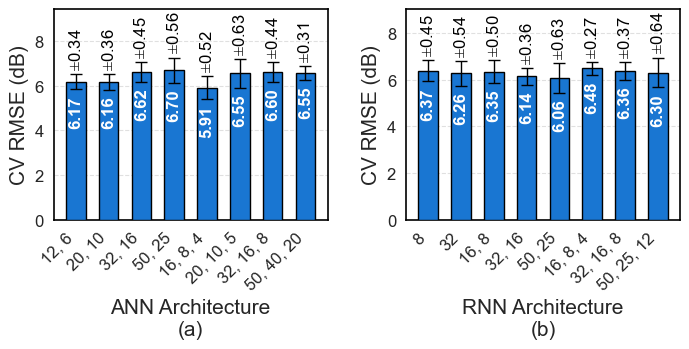

Saved figure: Figures/ANN_RNN_bestRMSE_STD_combination.png


In [24]:
# Plot and save ANN and RNN CV RMSE by selected architecture, side by side, 2 columns
# Reuses bar_color / annotate_bar / style_panel defined in the Setup cell above.

tick_fontsize = 12

fig, (ax_ann, ax_rnn) = plt.subplots(1, 2, figsize=(7, 3.6))

#  ANN panel 
x_ann = np.arange(len(cv_ann_df))
ax_ann.bar(
    x_ann,
    cv_ann_df["CV_RMSE"],
    width=0.6,
    yerr=cv_ann_df["STD_RMSE"],
    capsize=4,
    color=bar_color,
    edgecolor="black",
    linewidth=1,
    zorder=3,
    error_kw=dict(elinewidth=1, capthick=1),
)
for xi, cv, sd in zip(x_ann, cv_ann_df["CV_RMSE"], cv_ann_df["STD_RMSE"]):
    annotate_bar(ax_ann, xi, cv, sd)

ax_ann.set_xticks(x_ann)
ax_ann.set_xticklabels(cv_ann_df["arch_label"], rotation=45, ha="right", fontsize=tick_fontsize)
y_top_ann = float((cv_ann_df["CV_RMSE"] + cv_ann_df["STD_RMSE"]).max())
ax_ann.set_ylim(0, y_top_ann * 1.3)
style_panel(ax_ann, "ANN Architecture", "(a)")

#  RNN panel 
x_rnn = np.arange(len(cv_rnn_df))
ax_rnn.bar(
    x_rnn,
    cv_rnn_df["CV_RMSE"],
    width=0.6,
    yerr=cv_rnn_df["STD_RMSE"],
    capsize=4,
    color=bar_color,
    edgecolor="black",
    linewidth=1,
    zorder=3,
    error_kw=dict(elinewidth=1, capthick=1),
)
for xi, cv, sd in zip(x_rnn, cv_rnn_df["CV_RMSE"], cv_rnn_df["STD_RMSE"]):
    annotate_bar(ax_rnn, xi, cv, sd)

ax_rnn.set_xticks(x_rnn)
ax_rnn.set_xticklabels(cv_rnn_df["arch_label"], rotation=45, ha="right", fontsize=tick_fontsize)
y_top_rnn = float((cv_rnn_df["CV_RMSE"] + cv_rnn_df["STD_RMSE"]).max())
ax_rnn.set_ylim(0, y_top_rnn * 1.3)
style_panel(ax_rnn, "RNN Architecture", "(b)")

fig.tight_layout(w_pad=2.5) # gap between the two panels 

fig_path = os.path.join(FIGURES_DIR, "ANN_RNN_bestRMSE_STD_combination.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

plt.show()
print(f"Saved figure: {fig_path}")